In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


# Step 2: Load and Preprocess Dataset

In [2]:
# Define various terms
IMAGE_SIZE = 300
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 10

# Load dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    'C:\\Users\\Students\\Downloads\\Data',
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

# Define class names
class_names = dataset.class_names

# Split dataset into train, validation, and test sets
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset = dataset.take(train_size)
test_dataset = dataset.skip(train_size)
val_dataset = test_dataset.skip(val_size)
test_dataset = test_dataset.take(test_size)

# Configure datasets for better performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)


Found 16893 files belonging to 9 classes.


# Step 3: Data Augmentation and Preprocessing Layers

In [3]:
# Data augmentation and preprocessing layers
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0 / 255),
])

data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
])


# Step 4: Model Definition and Compilation

In [4]:
# Model definition
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)


# Step 5: Model Training

In [5]:
# Train the model
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset
)


Epoch 1/10


422/422 [==============================] - 942s 2s/step - loss: 0.6903 - accuracy: 0.7487 - val_loss: 0.3799 - val_accuracy: 0.8696
Epoch 2/10
422/422 [==============================] - 887s 2s/step - loss: 0.3372 - accuracy: 0.8768 - val_loss: 0.2594 - val_accuracy: 0.9072
Epoch 3/10
422/422 [==============================] - 882s 2s/step - loss: 0.2518 - accuracy: 0.9056 - val_loss: 0.2150 - val_accuracy: 0.9194
Epoch 4/10
422/422 [==============================] - 947s 2s/step - loss: 0.2144 - accuracy: 0.9175 - val_loss: 0.2349 - val_accuracy: 0.9009
Epoch 5/10
422/422 [==============================] - 887s 2s/step - loss: 0.1927 - accuracy: 0.9278 - val_loss: 0.1745 - val_accuracy: 0.9409
Epoch 6/10
422/422 [==============================] - 780s 2s/step - loss: 0.1720 - accuracy: 0.9362 - val_loss: 0.1761 - val_accuracy: 0.9345
Epoch 7/10
422/422 [==============================] - 772s 2s/step - loss: 0.1512 - accuracy: 0.9419 - val_loss: 0.1473 - val_accuracy: 0.94

In [6]:
scores = model.evaluate(test_dataset)

54/54 [==============================] - 62s 426ms/step - loss: 0.1032 - accuracy: 0.9682


In [7]:
scores

[0.10321655124425888, 0.9681712985038757]

In [8]:
history.params
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [9]:
accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

In [10]:
loss = history.history['loss']
validation_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Accuracy')

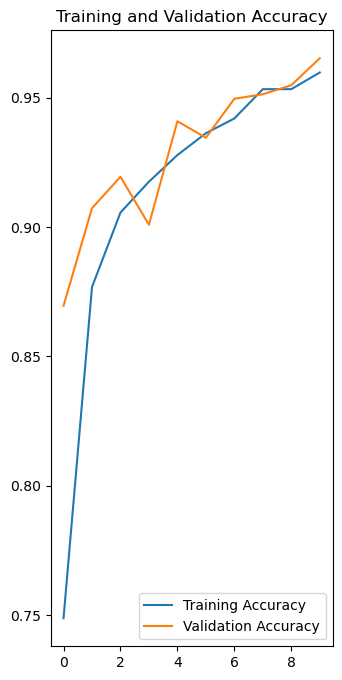

In [11]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), accuracy, label='Training Accuracy')
plt.plot(range(EPOCHS), validation_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')


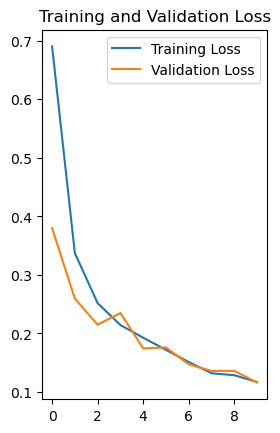

In [12]:
plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), validation_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

actual label:  Broadleaf
1/1 [==============================] - 1s 1s/step
predicted label:  Broadleaf


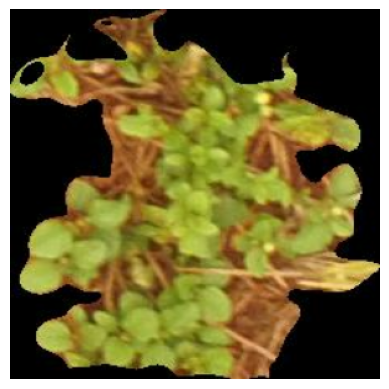

In [13]:
import numpy as np

for images_batch, labels_batch in test_dataset.take(1):
  first_image = images_batch[0].numpy().astype('uint8')
  first_label = labels_batch[0]
  plt.axis("off")

  #print("first image to predict")
  plt.imshow(first_image)
  print("actual label: ", class_names[first_label])

  batch_prediction = model.predict(images_batch)
  print("predicted label: ", class_names[np.argmax(batch_prediction[0])])#argmax help you choose to take accuracy


In [14]:
def predict(model, img):
  img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array = tf.expand_dims(img_array, 0)  #creating a batch

  predictions = model.predict(img_array)

  predicted_class = class_names[np.argmax(predictions[0])]
  confidence = round(100 * (np.max(predictions[0])), 2)
  return predicted_class, confidence
#here the confidence score is accuracy

1/1 [==============================] - 0s 17ms/step


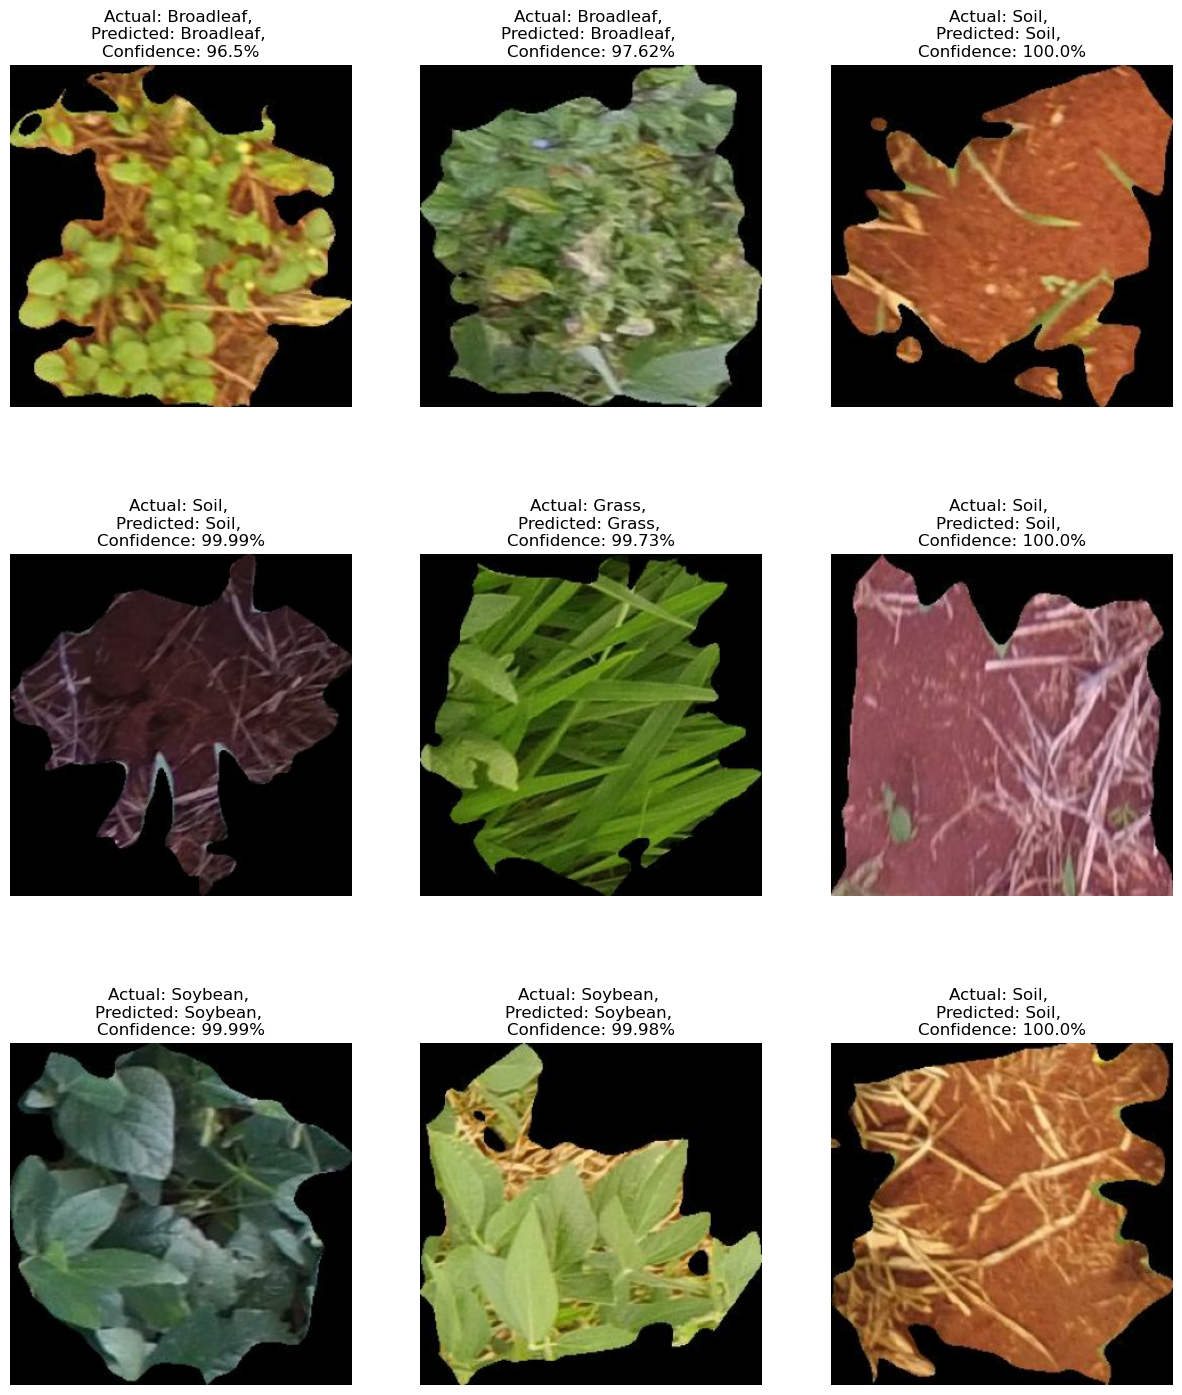

In [15]:
plt.figure(figsize = (15, 18))
for images, labels in test_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis("off")

    predicted_class, confidence = predict(model, images[i].numpy())
    actual_class = class_names[labels[i]]

    plt.title(f"Actual: {actual_class}, \nPredicted: {predicted_class}, \nConfidence: {confidence}%")

In [16]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

In [17]:

# Create an empty list to store true labels and predicted labels
y_true = []
y_pred = []

In [19]:
# Iterate over the entire dataset
for images_batch, labels_batch in dataset:
    batch_predictions = model.predict(images_batch)
    batch_pred_classes = np.argmax(batch_predictions, axis=1)
    y_true.extend(labels_batch.numpy())
    y_pred.extend(batch_pred_classes)

1/1 [==============================] - 0s 324ms/step


In [20]:

conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[ 1396     0     0     0    32     6     0     0     0]
 [    0  1942     0   284     8     0     0   144     4]
 [    2     0    14     2    12     8     0     4     2]
 [    0   200     4  6648    28     0     8   150     2]
 [   36     0     0     0   390     2     0     2     0]
 [   12     0     0     0     0  1154     0     0     0]
 [    0     0     0     0     0     0  6498     0     0]
 [    0    16     4    58     2     6     0 14662     4]
 [    8     0     0     0     2     0     4     0    26]]


In [21]:
# Calculate true positive rate (sensitivity/recall)
true_positives = conf_matrix[1, 1]
total_actual_positives = np.sum(conf_matrix[1, :])
true_positive_rate = true_positives / total_actual_positives

In [22]:
true_positives = conf_matrix[1, 1]

In [23]:
# Calculate false negative rate
false_negatives = conf_matrix[1, 0]
false_negatives_rate = false_negatives / total_actual_positives

In [24]:
# Print true positive rate and false negative rate
print("True Positive Rate (Sensitivity/Recall):", true_positive_rate)
print("False Negative Rate:", false_negatives_rate)


True Positive Rate (Sensitivity/Recall): 0.815281276238455
False Negative Rate: 0.0


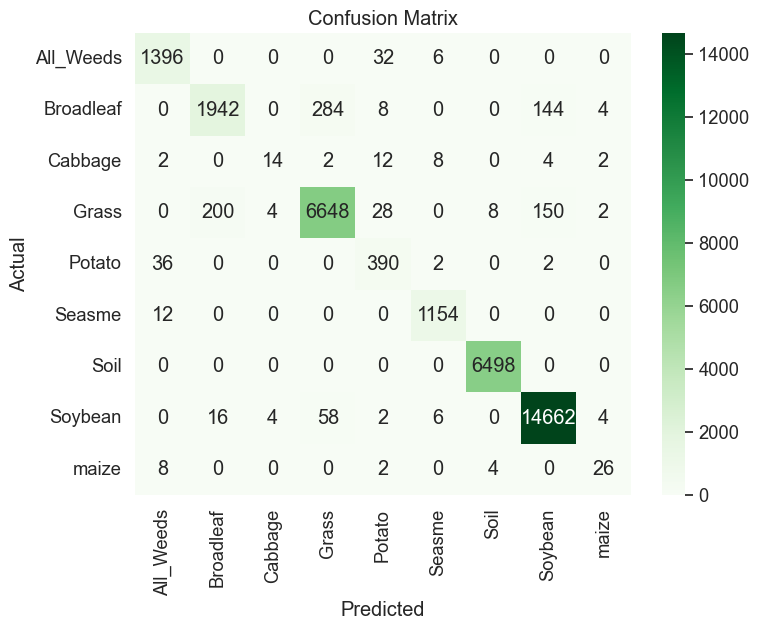

In [25]:
# Create a heatmap of the confusion matrix
class_names = ['All_Weeds','Broadleaf','Cabbage','Grass','Potato','Seasme','Soil','Soybean','maize']
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, labels=np.unique(y_true)))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1434
           1       0.90      0.82      0.86      2382
           2       0.64      0.32      0.42        44
           3       0.95      0.94      0.95      7040
           4       0.82      0.91      0.86       430
           5       0.98      0.99      0.99      1166
           6       1.00      1.00      1.00      6498
           7       0.98      0.99      0.99     14752
           8       0.68      0.65      0.67        40

    accuracy                           0.97     33786
   macro avg       0.88      0.84      0.85     33786
weighted avg       0.97      0.97      0.97     33786

